# 05 Robustness to obfuscation (E6, E7)

Attacks: `src/perturb.py`. Every model is attacked on the same trigger words (ranked by rung 2's occlusion). Defences: normalisation at inference (`+norm`) and adversarial training (`advtrain`).

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../.cache/mpl'))
import pandas as pd
from IPython.display import Image, Markdown, display
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 200)
from src import config
S = pd.read_csv(config.RESULTS / 'experiments.csv')          # mean (and sd) over seeds
BY_SEED = pd.read_csv(config.RESULTS / 'experiments_by_seed.csv')

def table(models, sets, variant='clean', split='template', metric='f1'):
    t = S[S.model.isin(models) & S.set.isin(sets) & (S.variant == variant) & (S.split == split)]
    return t.pivot_table(index='model', columns='set', values=metric).reindex(models).round(3)

## What the attacks look like

In [2]:
ev = pd.read_csv(config.DATA_PROCESSED / 'eval_template.csv', keep_default_na=False)
clean = ev[ev.set == 'test'].set_index('id').text
sid = ev[(ev.set == 'test') & (ev.label == 1)].id.iloc[3]
for s in ['test', 'test_lookalike_3', 'test_structural_3', 'test_codeswitch_3', 'test_lookalike_all', 'test_lookalike_all+norm']:
    print(f'{s:26s}', ev[(ev.set == s) & (ev.id == sid)].text.iloc[0])

test                       Habari za asubuhi. Mimi mwenye nyumba wako hii namba yangu ya Vodacom. Mbona kimya na siku zinazidi kwenda...?
test_lookalike_3           Habari za asubuhi. Mimi mwe​nуе nyumba wako hii n4​mba yangu ya Vоdа​сom. Mbona kimya na siku zinazidi kwenda...?
test_structural_3          Habari za asubuhi. Mimi m-w-e-n-y-e nyumba wako hii n-a-m-b-a yangu ya V o d a c o m . Mbona kimya na siku zinazidi kwenda...?
test_codeswitch_3          Habari za asubuhi. Mimi landlord wako hii number yangu ya Vodacom. Mbona kimya na siku zinazidi kwenda...?
test_lookalike_all         Hab​аrі za asubuhi. Мi​mi mwe​nуе nуu​mb4 wako h​iі nа​mba уа​ngu ya Vodа​соm. Mb​оnа k1​my4 na siku zinazidi kwenda...?
test_lookalike_all+norm    Habari za asubuhi. Mimi mwenye nyumba wako hii namba yangu ya Vodacom. Mbona <AMOUNT> mya na siku zinazidi kwenda...?


## The code-switching lexicon comes from the data

Each of the 30 Swahili phrases, how many training messages contain it, and the share of those that are scams.

In [3]:
import re
from src.perturb import LEXICON
from src.data import load_bongo
tr = load_bongo().query("split_template == 'train'")
rows = []
for k, v in LEXICON.items():
    m = tr.text.str.contains(r'(?<!\w)' + re.escape(k) + r'(?!\w)', case=False, regex=True)
    rows.append({'swahili': k, 'english': v, 'train messages': int(m.sum()), 'scam share': round(tr[m].label.mean(), 2)})
lex = pd.DataFrame(rows)
print('median scam share:', lex['scam share'].median(), '| phrases with scam share >= 0.8:', (lex['scam share'] >= 0.8).sum())
lex

median scam share: 1.0 | phrases with scam share >= 0.8: 27


,swahili,english,train messages,scam share
0,kwenye namba hii,to this number,66,1.00
1,namba hii,this number,122,1.00
2,mwenye nyumba,landlord,9,1.00
3,nitumie,send me,66,0.95
4,unitumie,send me,22,0.91
5,utanitumia,you will send me,56,1.00
6,itume,send it,44,1.00
7,tuma,send,68,1.00
8,namba,number,235,0.98
9,jina,name,260,1.00


## E6: relative F1 drop

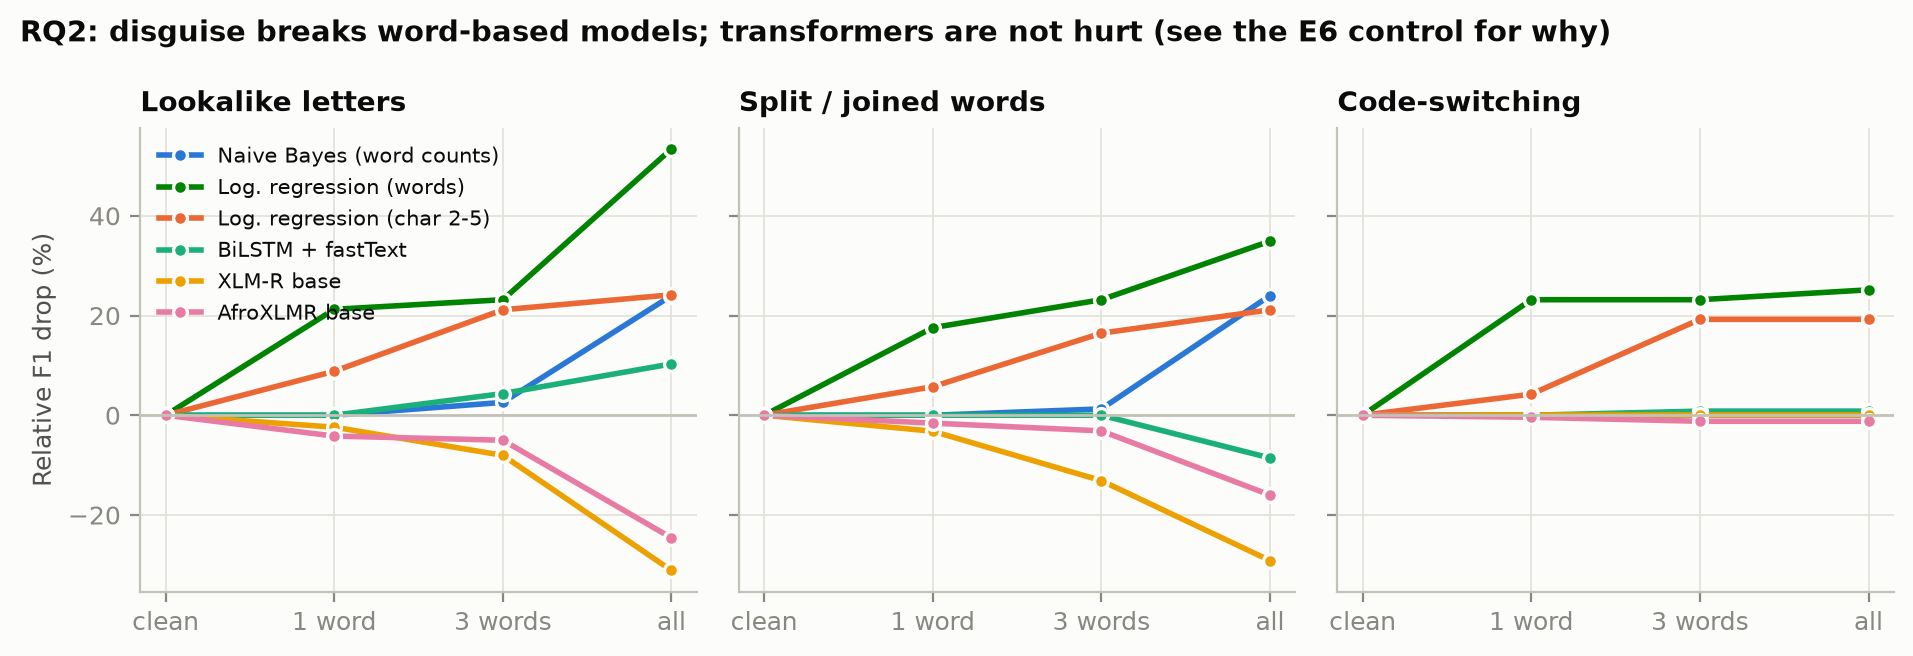

In [4]:
display(Image(str(config.FIGURES / 'rq2_attacks.png')))

In [5]:
models = ['nb_word_counts', 'lr_word', 'lr_char', 'bilstm_finetuned', 'xlmr', 'afroxlmr']
sets = [f'test_{a}_{k}' for a in ('lookalike', 'structural', 'codeswitch') for k in ('1', '3', 'all')]
table(models, sets, metric='rel_f1_drop')

set,test_codeswitch_1,test_codeswitch_3,test_codeswitch_all,test_lookalike_1,test_lookalike_3,test_lookalike_all,test_structural_1,test_structural_3,test_structural_all
model,,,,,,,,,
nb_word_counts,0.000,0.000,0.000,0.000,0.026,0.240,0.000,0.013,0.240
lr_word,0.232,0.232,0.252,0.212,0.232,0.534,0.176,0.232,0.349
lr_char,0.042,0.192,0.192,0.088,0.212,0.242,0.057,0.165,0.212
bilstm_finetuned,0.000,0.008,0.008,0.000,0.044,0.103,0.000,0.000,-0.086
xlmr,0.000,0.000,0.000,-0.024,-0.080,-0.311,-0.032,-0.131,-0.292
afroxlmr,-0.004,-0.012,-0.012,-0.042,-0.050,-0.246,-0.016,-0.031,-0.160


Recall on attacked scams (the share of disguised scams still caught):

In [6]:
table(models, ['test'] + sets, metric='recall')

set,test,test_codeswitch_1,test_codeswitch_3,test_codeswitch_all,test_lookalike_1,test_lookalike_3,test_lookalike_all,test_structural_1,test_structural_3,test_structural_all
model,,,,,,,,,,
nb_word_counts,1.000,1.000,1.000,1.000,1.000,0.951,0.617,1.000,0.975,0.617
lr_word,0.963,0.605,0.605,0.580,0.630,0.605,0.296,0.679,0.605,0.469
lr_char,0.938,0.864,0.642,0.642,0.790,0.617,0.580,0.840,0.679,0.617
bilstm_finetuned,0.617,0.617,0.609,0.609,0.617,0.576,0.523,0.617,0.617,0.708
xlmr,0.617,0.617,0.617,0.617,0.642,0.704,1.000,0.650,0.765,0.971
afroxlmr,0.634,0.638,0.646,0.646,0.679,0.687,0.934,0.650,0.667,0.819


## E7: defences

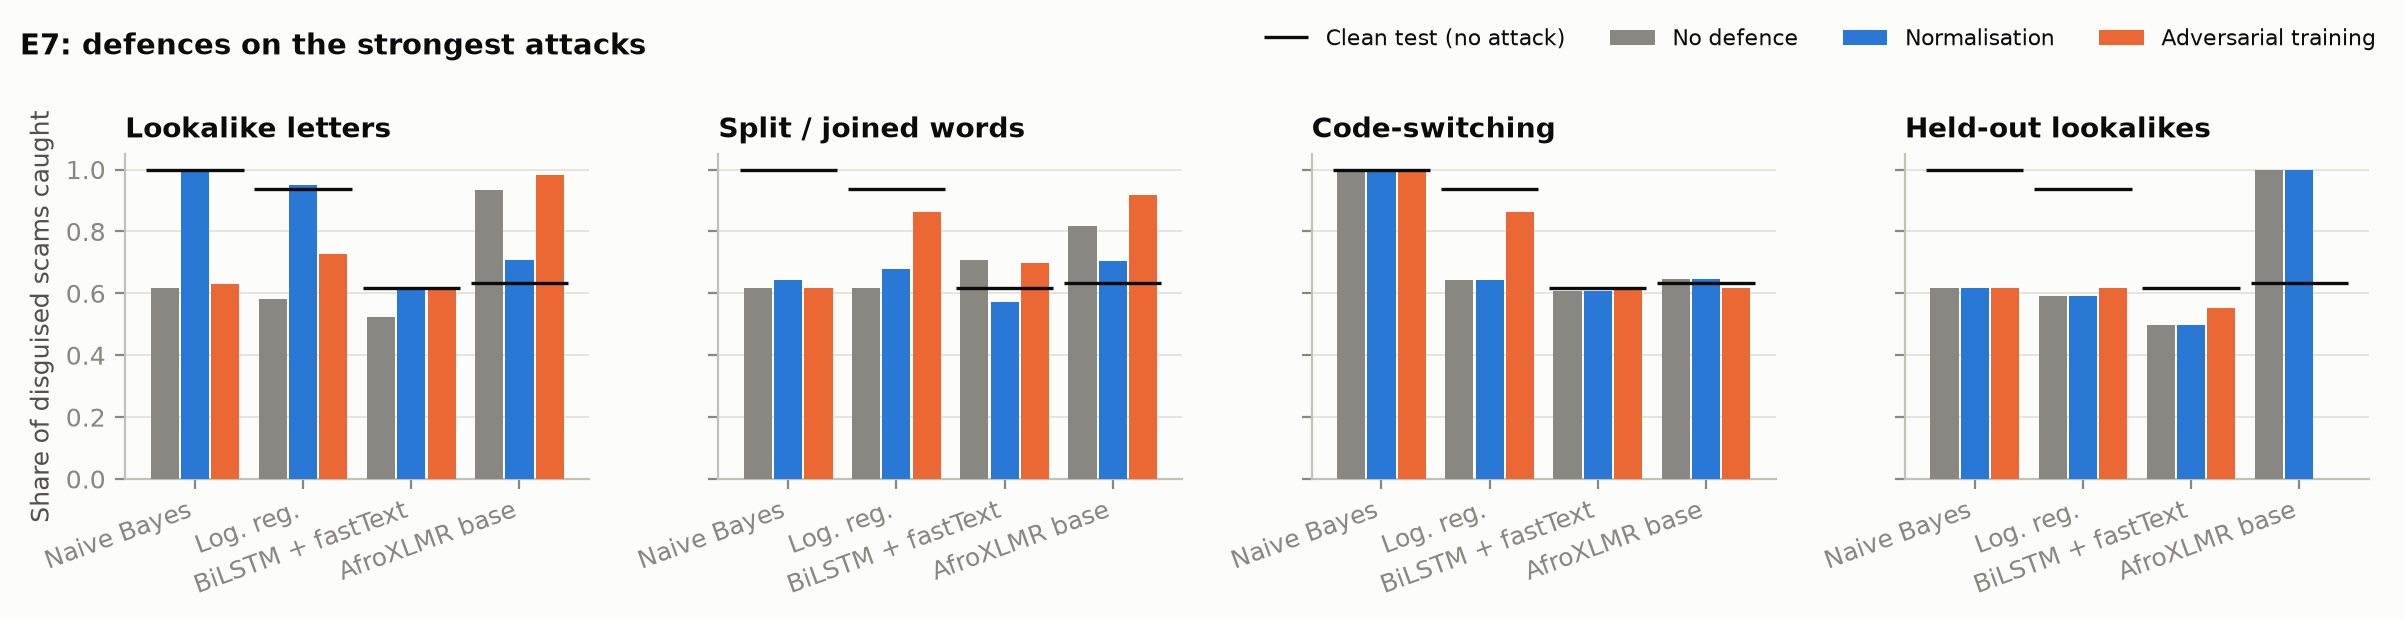

In [7]:
display(Image(str(config.FIGURES / 'rq2_defences.png')))

In [8]:
rows = []
for m in ['nb_word_counts', 'lr_char', 'bilstm_finetuned', 'afroxlmr']:
    for v in ['clean', 'advtrain']:
        for suffix in ['', '+norm']:
            r = S[(S.model == m) & (S.variant == v) & (S.split == 'template')]
            if r.empty: continue
            row = {'model': m, 'training': v, 'defence': suffix or 'none', 'clean F1': r[r.set == 'test' + suffix].f1.mean()}
            for a in ('lookalike', 'structural', 'codeswitch'):
                row[a] = r[r.set == f'test_{a}_all{suffix}'].f1.mean()
            rows.append(row)
pd.DataFrame(rows).round(3)

,model,training,defence,clean F1,lookalike,structural,codeswitch
0,nb_word_counts,clean,none,0.982,0.746,0.746,0.982
1,nb_word_counts,clean,+norm,0.982,0.982,0.765,0.982
2,nb_word_counts,advtrain,none,0.982,0.756,0.746,0.982
3,nb_word_counts,advtrain,+norm,0.982,0.982,0.774,0.982
4,lr_char,clean,none,0.968,0.734,0.763,0.782
5,lr_char,clean,+norm,0.968,0.975,0.809,0.782
6,lr_char,advtrain,none,0.962,0.837,0.921,0.921
7,lr_char,advtrain,+norm,0.962,0.969,0.820,0.921
8,bilstm_finetuned,clean,none,0.763,0.685,0.829,0.757
9,bilstm_finetuned,clean,+norm,0.763,0.763,0.728,0.757


**Reading.** Word-level models break under lookalike letters (the disguised words become unseen tokens). Normalisation undoes these lookalikes almost completely for classical models at no cost on clean text (its table covers every character the attack uses, so this is a best case; see the held-out check below), but only partly repairs structural attacks: neighbouring spaced-out words are rejoined into one token and glued words stay glued. The transformers lose nothing under disguise, but the control sets (genuine texts disguised the same way) show why: with every word disguised, XLM-R flags 93% of genuine texts and AfroXLMR 54-60%, and the scams AfroXLMR catches only once disguised are mostly the landlord script it misses when clean. So their "robustness" is largely suspicion of odd-looking text. The char LR never flags disguised genuine texts but loses 21-24% of its F1. A second attacker (word-count NB) gives the same picture, so this is not an artefact of the char-LR attacker. Code-switching is the attack normalisation cannot undo; adversarial training cuts the char LR's loss there from 19% to 4%.

## E7 check: held-out lookalikes

The normalisation table was written knowing the lookalike attack's characters. This attack disguises the same trigger words with lookalike characters the table does not know (`perturb.UNSEEN`: Latin IPA, Armenian, Cherokee, Coptic and other Cyrillic letters, and a different invisible character). Scam F1 at full intensity:

In [9]:
table(['nb_word_counts', 'lr_word', 'lr_char', 'bilstm_finetuned', 'xlmr', 'afroxlmr'], ['test', 'test_lookalike_all', 'test_lookalike_all+norm', 'test_unseen_all', 'test_unseen_all+norm'])

set,test,test_lookalike_all,test_lookalike_all+norm,test_unseen_all,test_unseen_all+norm
model,,,,,
nb_word_counts,0.982,0.746,0.982,0.746,0.746
lr_word,0.981,0.457,0.975,0.540,0.540
lr_char,0.968,0.734,0.975,0.744,0.744
bilstm_finetuned,0.763,0.685,0.763,0.662,0.662
xlmr,0.760,0.996,0.796,0.996,0.996
afroxlmr,0.776,0.965,0.829,1.000,1.000


**Reading.** On held-out lookalikes normalisation recovers nothing: every model scores the same with and without it (word LR 0.54, char LR 0.74), because the table only maps the characters it lists. The lookalike recovery above is therefore a best case for a defence that knows the tricks in use; a general defence needs a far larger confusables list or visual character embeddings (Eger et al., 2019). The transformers again catch every disguised scam, consistent with flagging odd-looking text.